In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import time
import random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
random.seed(42)
np.random.seed(42)
os.environ["PYTHONHASHSEED"] = str(42)
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
data_dir = './data'
train_path = './data/Train'
test_path = './data'

In [4]:
class GTSRBDataset(Dataset):
    def __init__(self, root_dir, transform=None, is_train=True):
        self.root_dir = root_dir
        self.transform = transform
        self.is_train = is_train
        if self.is_train:
            self.samples = []
            for class_id in sorted(os.listdir(root_dir)):
                class_path = os.path.join(root_dir, class_id)
                if os.path.isdir(class_path):
                    for img_name in sorted(os.listdir(class_path)):
                        if img_name.endswith('.png'):
                            self.samples.append((os.path.join(class_path, img_name), int(class_id)))
        else:
            self.csv_data = pd.read_csv(os.path.join(root_dir, 'Test.csv'))
    def __len__(self):
        return len(self.samples) if self.is_train else len(self.csv_data)
    def __getitem__(self, idx):
        if self.is_train:
            img_path, label = self.samples[idx]
        else:
            row = self.csv_data.iloc[idx]
            img_path = os.path.join(self.root_dir, row['Path'])
            label = int(row['ClassId'])
        image = Image.open(img_path).convert('RGB')
        if self.transform: image = self.transform(image)
        return image, label

In [5]:
def print_parameters(model, model_name, verbose=True):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    if verbose:
        print(f"\n{'='*20} [{model_name} Layer Details] {'='*20}")
        print(f"{'Layer Name':<40} | {'Shape':<25} | {'Parameters':<15}")
        print("-" * 85)
        for name, param in model.named_parameters():
            if param.requires_grad:
                num = param.numel()
                shape_str = str(list(param.shape))
                print(f"{name:<40} | {shape_str:<25} | {num:>15,}")
        print("-" * 85)
        print(f"{'TOTAL TRAINABLE PARAMETERS':<68} | {total_params:>15,}")
        print('='*85)
    return total_params

In [6]:
def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs, model_name):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': [], 'time': []}
    best_val_acc = 0.0
    for epoch in range(num_epochs):
        epoch_start = time.time()
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                val_loss += criterion(outputs, labels).item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
        curr_val_acc = val_correct / val_total
        history['loss'].append(train_loss/len(train_loader))
        history['accuracy'].append(train_correct/train_total)
        history['val_loss'].append(val_loss/len(test_loader))
        history['val_accuracy'].append(curr_val_acc)
        history['time'].append(time.time() - epoch_start)
        print(f"Epoch {epoch+1} | Loss: {history['loss'][-1]:.4f} | Acc: {history['accuracy'][-1]*100:.2f}% | Val Acc: {curr_val_acc*100:.2f}%")
        if curr_val_acc > best_val_acc:
            best_val_acc = curr_val_acc
            torch.save(model.state_dict(), f'best_{model_name}.pth')
    return history

In [7]:
class NaiveCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=5) 
        self.conv2 = nn.Conv2d(32, 64, kernel_size=5)
        self.pool1 = nn.MaxPool2d(kernel_size=2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3)
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        # 30x30 입력 시 Flatten 크기: 256 * 3 * 3 = 2304
        self.fc1 = nn.Linear(2304, 512)
        self.fc2 = nn.Linear(512, 43)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool1(x)

        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool2(x)

        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [8]:
transform_30 = transforms.Compose([transforms.Resize((30, 30)), transforms.ToTensor()])
train_loader = DataLoader(GTSRBDataset(train_path, transform_30), batch_size=64, shuffle=True)
test_loader = DataLoader(GTSRBDataset(test_path, transform_30, is_train=False), batch_size=64, shuffle=False)

model = NaiveCNN()
history = train_model(model, train_loader, test_loader, nn.CrossEntropyLoss(), optim.Adam(model.parameters(), lr=0.001), 10, "NaiveCNN")

Epoch 1 | Loss: 1.0204 | Acc: 70.57% | Val Acc: 91.81%
Epoch 2 | Loss: 0.0806 | Acc: 97.78% | Val Acc: 94.62%
Epoch 3 | Loss: 0.0395 | Acc: 98.89% | Val Acc: 95.53%
Epoch 4 | Loss: 0.0268 | Acc: 99.22% | Val Acc: 95.50%
Epoch 5 | Loss: 0.0282 | Acc: 99.17% | Val Acc: 94.98%
Epoch 6 | Loss: 0.0243 | Acc: 99.26% | Val Acc: 95.19%
Epoch 7 | Loss: 0.0180 | Acc: 99.52% | Val Acc: 95.38%
Epoch 8 | Loss: 0.0187 | Acc: 99.49% | Val Acc: 94.89%
Epoch 9 | Loss: 0.0169 | Acc: 99.53% | Val Acc: 95.77%
Epoch 10 | Loss: 0.0154 | Acc: 99.58% | Val Acc: 95.92%


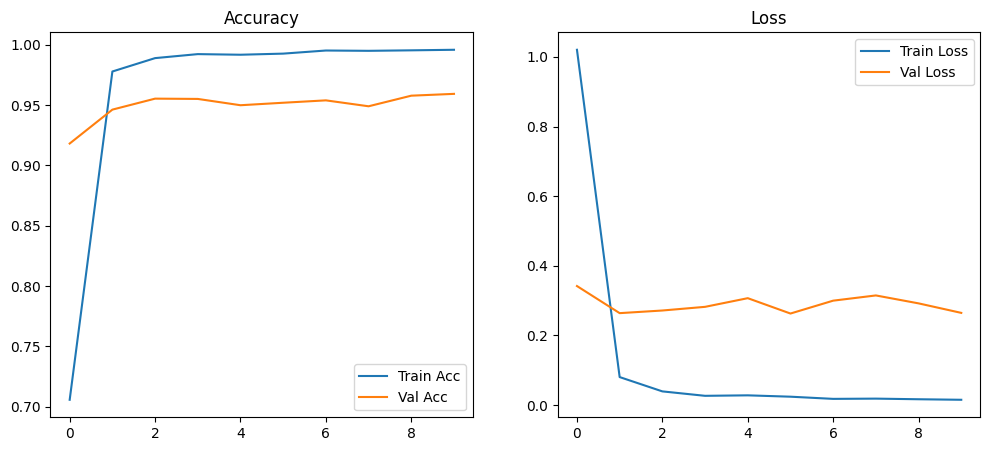

In [9]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Train Acc')
plt.plot(history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

In [10]:
def evaluate_model(model, test_loader, model_name):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    correct = 0
    total = 0
    print(f"--- Evaluating {model_name} ---")
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    final_acc = 100 * correct / total
    print(f"Total Images: {total}")
    print(f"Correct: {correct}")
    print(f"Accuracy: {final_acc:.2f}%\n")
    return final_acc

In [11]:
print_parameters(model, "NaiveCNN")
evaluate_model(model, test_loader, "NaiveCNN")


==================== [NaiveCNN Layer Details] ====================
Layer Name                               | Shape                     | Parameters     
-------------------------------------------------------------------------------------
conv1.weight                             | [32, 3, 5, 5]             |           2,400
conv1.bias                               | [32]                      |              32
conv2.weight                             | [64, 32, 5, 5]            |          51,200
conv2.bias                               | [64]                      |              64
conv3.weight                             | [128, 64, 3, 3]           |          73,728
conv3.bias                               | [128]                     |             128
conv4.weight                             | [256, 128, 3, 3]          |         294,912
conv4.bias                               | [256]                     |             256
fc1.weight                               | [512, 2304]         

95.92240696753761